## Latihan Mandiri
**Nama : Shahida Shintya**  
**NIM : 2411511007**

### 1. Klasifikasi Flynn: Untuk masing-masing skenario berikut, tentukan kategori Flynn (SISD/SIMD/MISD/MIMD) beserta alasannya:  
**Operasi arr + arr pada NumPy array**   
jawab : SIMD karena satu operasi yang sama dilakukan secara bersamaan pada banyak elemen array.

**Program Python biasa (tanpa threading/multiprocessing) yang membaca file lalu memproses baris demi baris**  
jawab: SISD karena instruksi dijalankan secara berurutan pada satu aliran data, tanpa threading atau multiprocessing.    


**Cluster komputer yang masing-masing node menjalankan simulasi cuaca berbeda untuk wilayah berbeda secara independen**  
jawab: MIMD karena setiap node menjalankan instruksi dan data yang berbeda secara independen.

### 2. Analisis Amdahl: Sebuah aplikasi pengolahan citra memiliki proporsi paralel $P = 0.85$.
#### Hitung speedup teoritis untuk $N = 2, 4, 8, 16, 32, 64$ (gunakan fungsi amdahl_speedup di atas)   
jawab:    



In [2]:
import numpy as np
import matplotlib.pyplot as plt

def amdahl_speedup(P, N):
    return 1 / ((1 - P) + P / N)

P = 0.85
N = np.array([2, 4, 8, 16, 32, 64])

speedup = amdahl_speedup(P, N)

print("Hasil Speedup Amdahl:")
for n, s in zip(N, speedup):
    print(f"N = {n:2d} -> Speedup = {s:.3f}")


Hasil Speedup Amdahl:
N =  2 -> Speedup = 1.739
N =  4 -> Speedup = 2.759
N =  8 -> Speedup = 3.902
N = 16 -> Speedup = 4.923
N = 32 -> Speedup = 5.664
N = 64 -> Speedup = 6.124


#### Buat plot speedup vs $N$   
      

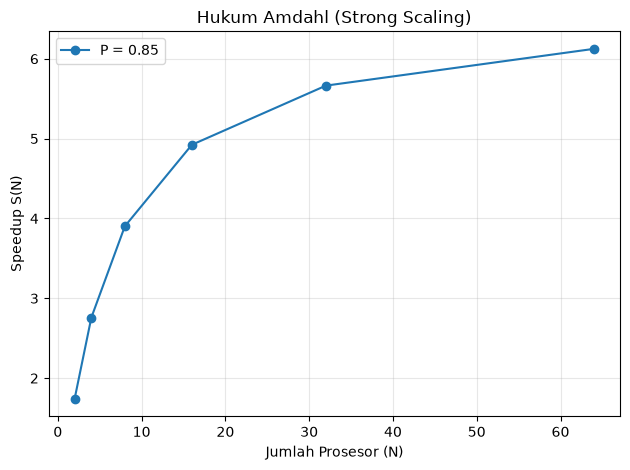

In [3]:
plt.plot(N, speedup, marker='o', label=f"P = {P}")
plt.title("Hukum Amdahl (Strong Scaling)")
plt.xlabel("Jumlah Prosesor (N)")
plt.ylabel("Speedup S(N)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Pada $N$ berapa penambahan prosesor mulai memberikan manfaat yang sangat kecil ("diminishing returns")? Jelaskan alasan kalian.  
Semakin banyak prosesor, peningkatan speedup semakin kecil.Diminishing returns mulai terlihat sekitar N = 16. Setelah itu, penambahan prosesor masih meningkatkan speedup, tetapi peningkatannya semakin kecil. Hal ini terjadi karena ada bagian program bersifat serial dan tidak dapat diparalelkan. Berdasarkan hasil, speedup hanya naik dari 4.923 pada N = 16 menjadi 6.124 pada N = 64, sehingga penambahan prosesor semakin kurang efektif.

### 3. Benchmark mandiri: Ambil salah satu fungsi CPU-bound buatan sendiri (boleh modifikasi hitung_prima, atau buat fungsi lain seperti menghitung deret Fibonacci naif secara rekursif). Ukur waktu eksekusinya untuk minimal 4 ukuran input berbeda menggunakan time.perf_counter() dan timeit, lalu bandingkan hasil keduanya dalam satu tabel/plot.

Ukuran Input (N)   | perf_counter() (s)   | timeit (s)     
------------------------------------------------------------
1000               | 0.000998             | 0.005664       
5000               | 0.007019             | 0.015900       
10000              | 0.021707             | 0.018786       
20000              | 0.031705             | 0.029311       


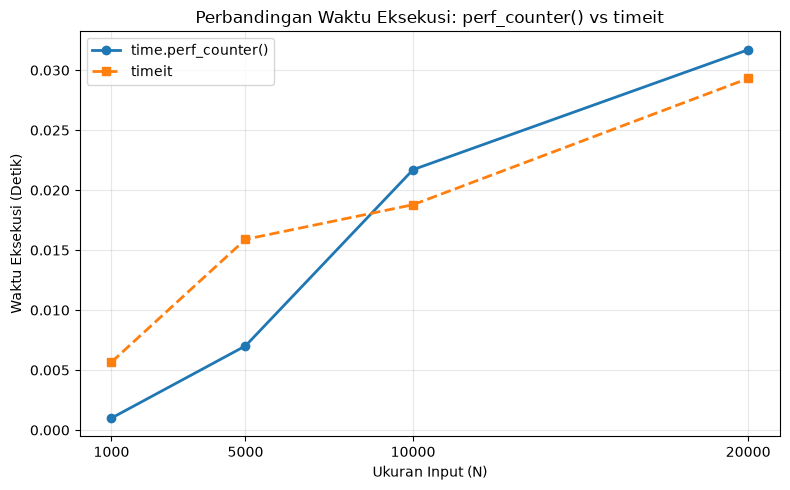

In [11]:
import time
import timeit
import matplotlib.pyplot as plt

def hitung_prima(n):
    count = 0
    for i in range(2, n):
        is_prime = True
        for j in range(2, int(i**0.5) + 1):
            if i % j == 0:
                is_prime = False
                break
        if is_prime:
            count += 1
    return count

# Ukuran input yang diuji
input_sizes = [1000, 5000, 10000, 20000]
waktu_perf = []
waktu_timeit = []

# Proses Pengukuran Waktu
print(f"{'Ukuran Input (N)':<18} | {'perf_counter() (s)':<20} | {'timeit (s)':<15}")
print("-" * 60)

for size in input_sizes:
    # Menggunakan time.perf_counter()
    t0 = time.perf_counter()
    hitung_prima(size)
    t1 = time.perf_counter()
    durasi_perf = t1 - t0
    waktu_perf.append(durasi_perf)
    
    # Menggunakan timeit
    durasi_timeit = timeit.timeit(lambda: hitung_prima(size), number=1)
    waktu_timeit.append(durasi_timeit)
    
    print(f"{size:<18} | {durasi_perf:<20.6f} | {durasi_timeit:<15.6f}")

plt.figure(figsize=(8, 5))
plt.plot(input_sizes, waktu_perf, marker='o', linewidth=2, label='time.perf_counter()', color='tab:blue')
plt.plot(input_sizes, waktu_timeit, marker='s', linestyle='--', linewidth=2, label='timeit', color='tab:orange')

plt.title('Perbandingan Waktu Eksekusi: perf_counter() vs timeit', fontsize=12)
plt.xlabel('Ukuran Input (N)', fontsize=10)
plt.ylabel('Waktu Eksekusi (Detik)', fontsize=10)
plt.xticks(input_sizes)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### 4. Refleksi singkat (maks. 150 kata): Menurut kalian, kapan Hukum Amdahl lebih relevan digunakan dibanding Hukum Gustafson, dan sebaliknya? Berikan satu contoh kasus nyata untuk masing-masing.
jawab: Menurut saya, Hukum Amdahl sangat cocok untuk strong scaling, di mana fokusnya adalah mempercepat pemrosesan beban kerja bernilai tetap. Contoh penerapannya adalah rendering animasi 3D resolusi 1080p, di mana penambahan core bertujuan murni memangkas durasi tunggu.

Sementara itu, Hukum Gustafson lebih pas untuk weak scaling, yakni memanfaatkan tambahan daya komputasi untuk menangani skala data yang lebih besar dalam batas waktu sama. Contoh kasus nyatanya terlihat pada simulasi prediksi cuaca global, di mana penambahan prosesor digunakan untuk meningkatkan kerapatan kisi (grid) simulasi agar hasilnya lebih akurat tanpa memperlambat proses analisis.